# 🎯 Lab 01: Embedding 基礎與視覺化

## 學習目標
在本實驗中，您將學習：
1. **Embedding 概念** - 理解什麼是 Embedding 以及為何需要它
2. **相似度計算** - 掌握 Cosine、Euclidean、Dot Product 三種相似度
3. **視覺化技術** - 使用 t-SNE / UMAP 視覺化 embedding space
4. **模型比較** - 比較不同預訓練模型的 embedding 品質

## 為什麼需要 Embedding？
- 電腦無法直接理解文字，需要轉換成數值向量
- 好的 Embedding 能捕捉語義相似性：「貓」和「狗」應該比「貓」和「汽車」更接近
- Embedding 是 RAG、推薦系統、語義搜索的核心基礎

## 技術棧
- **Embedding Models**: `sentence-transformers`
- **Visualization**: `matplotlib`, `umap-learn`, `scikit-learn`

---

## 📦 Part 1: 環境設置

In [1]:
# 安裝必要套件
!pip install --quiet sentence-transformers
!pip install --quiet umap-learn
!pip install --quiet matplotlib seaborn
!pip install --quiet scikit-learn
!pip install --quiet pandas numpy

In [2]:
# 匯入套件
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體 (如果需要)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 所有套件載入成功！")

✅ 所有套件載入成功！


---
## 🧠 Part 2: Embedding 基礎概念

### 什麼是 Embedding？

Embedding 是一種將離散物件（如文字、單詞）映射到連續向量空間的技術。

```
"我喜歡貓" → [0.12, -0.34, 0.56, ..., 0.78]  (384 維向量)
"我喜歡狗" → [0.11, -0.32, 0.58, ..., 0.75]  (384 維向量)
"量子力學" → [-0.45, 0.67, -0.12, ..., 0.23] (384 維向量)
```

語義相近的句子，其向量也會相近！

In [3]:
import os
from sentence_transformers import SentenceTransformer

# 設定本地 Hugging Face cache 目錄（在專案資料夾內）
os.environ["HF_HOME"] = "./hf_cache"
os.makedirs(os.environ["HF_HOME"], exist_ok=True)

# 載入預訓練模型
print("📥 正在載入模型 (首次執行需要下載，約 90MB)...")
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",  # 或 'all-MiniLM-L6-v2' 也可
    cache_folder="./hf_cache",                # 關鍵：指定到專案底下，不用 ~/.cache
)
print(f"✅ 模型載入完成！")
print(f"📐 輸出向量維度: {model.get_sentence_embedding_dimension()}")

📥 正在載入模型 (首次執行需要下載，約 90MB)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ 模型載入完成！
📐 輸出向量維度: 384


In [4]:
# 產生第一個 Embedding
sentence = "Hello, this is my first embedding!"
embedding = model.encode(sentence)

print(f"📝 輸入句子: '{sentence}'")
print(f"📐 向量維度: {embedding.shape}")
print(f"🔢 向量前 10 個值: {embedding[:10]}")
print(f"📊 向量統計: min={embedding.min():.4f}, max={embedding.max():.4f}, mean={embedding.mean():.4f}")

📝 輸入句子: 'Hello, this is my first embedding!'
📐 向量維度: (384,)
🔢 向量前 10 個值: [-0.01213645 -0.08020083  0.04008469 -0.00794929  0.01935152  0.03663864
 -0.00801659 -0.02127145  0.00411071 -0.03189709]
📊 向量統計: min=-0.1375, max=0.1939, mean=-0.0001


In [5]:
# 批次處理多個句子
sentences = [
    "I love cats",
    "I love dogs",
    "The weather is nice today",
    "Machine learning is interesting",
    "Deep learning requires GPUs",
    "I adore kittens",  # 語義上與 "I love cats" 相近
]

embeddings = model.encode(sentences)
print(f"✅ 產生了 {len(embeddings)} 個 embedding")
print(f"📐 Embeddings 矩陣形狀: {embeddings.shape}")

✅ 產生了 6 個 embedding
📐 Embeddings 矩陣形狀: (6, 384)


---
## 📏 Part 3: 相似度計算

### 三種常見的相似度/距離度量

1. **Cosine Similarity（餘弦相似度）**: 測量兩個向量的夾角，範圍 [-1, 1]
   - 1 = 完全相同方向
   - 0 = 正交（無關）
   - -1 = 完全相反

2. **Euclidean Distance（歐氏距離）**: 測量兩點之間的直線距離
   - 0 = 完全相同
   - 越大越不相似

3. **Dot Product（點積）**: 兩個向量的內積
   - 與 Cosine Similarity 成正比（當向量已正規化時）

In [6]:
# 手動實作三種相似度計算

def manual_cosine_similarity(a, b):
    """餘弦相似度: cos(θ) = (A·B) / (||A|| × ||B||)"""
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)

def manual_euclidean_distance(a, b):
    """歐氏距離: d = √(Σ(ai - bi)²)"""
    return np.sqrt(np.sum((a - b) ** 2))

def manual_dot_product(a, b):
    """點積: A·B = Σ(ai × bi)"""
    return np.dot(a, b)

# 測試：比較 "I love cats" 和 "I adore kittens"
emb_cats = embeddings[0]   # "I love cats"
emb_kittens = embeddings[5]  # "I adore kittens"
emb_weather = embeddings[2]  # "The weather is nice today"

print("🐱 'I love cats' vs 'I adore kittens' (語義相近):")
print(f"   Cosine Similarity: {manual_cosine_similarity(emb_cats, emb_kittens):.4f}")
print(f"   Euclidean Distance: {manual_euclidean_distance(emb_cats, emb_kittens):.4f}")
print(f"   Dot Product: {manual_dot_product(emb_cats, emb_kittens):.4f}")

print("\n🌤️ 'I love cats' vs 'The weather is nice today' (語義不同):")
print(f"   Cosine Similarity: {manual_cosine_similarity(emb_cats, emb_weather):.4f}")
print(f"   Euclidean Distance: {manual_euclidean_distance(emb_cats, emb_weather):.4f}")
print(f"   Dot Product: {manual_dot_product(emb_cats, emb_weather):.4f}")

🐱 'I love cats' vs 'I adore kittens' (語義相近):
   Cosine Similarity: 0.7318
   Euclidean Distance: 0.7324
   Dot Product: 0.7318

🌤️ 'I love cats' vs 'The weather is nice today' (語義不同):
   Cosine Similarity: 0.0975
   Euclidean Distance: 1.3435
   Dot Product: 0.0975


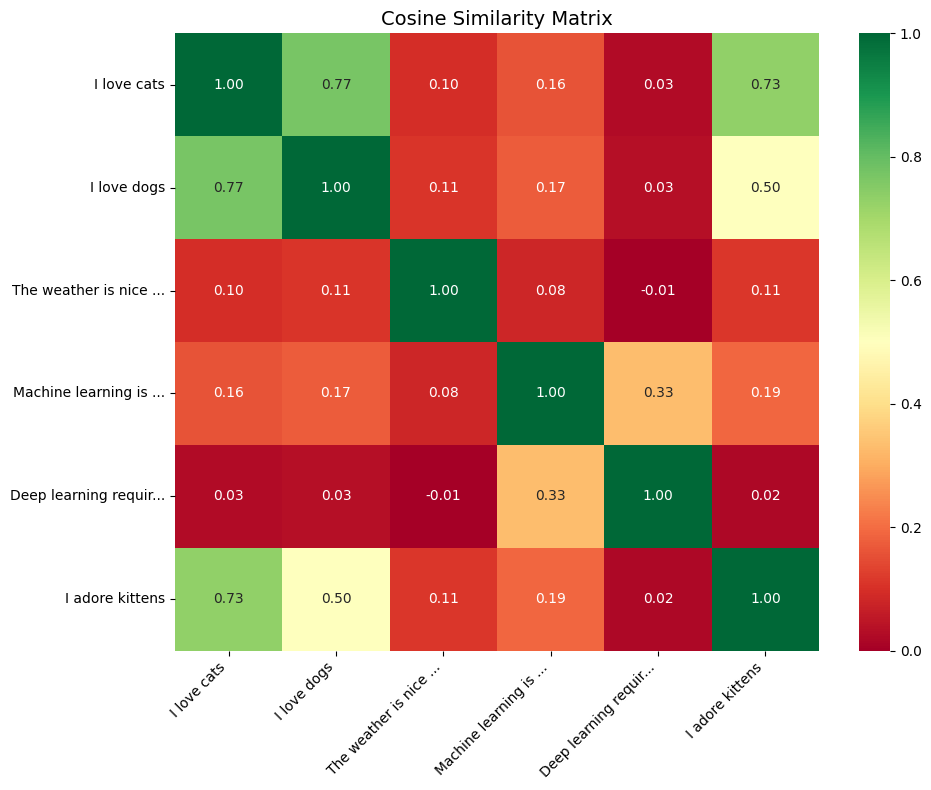


💡 觀察重點:
- 對角線都是 1.0 (自己與自己的相似度)
- 'I love cats' 和 'I adore kittens' 相似度很高
- 'Machine learning' 和 'Deep learning' 相似度也很高


In [7]:
# 計算完整的相似度矩陣
similarity_matrix = cosine_similarity(embeddings)

# 視覺化相似度矩陣
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.2f',
    xticklabels=[s[:20] + '...' if len(s) > 20 else s for s in sentences],
    yticklabels=[s[:20] + '...' if len(s) > 20 else s for s in sentences],
    cmap='RdYlGn',
    vmin=0, vmax=1
)
plt.title('Cosine Similarity Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n💡 觀察重點:")
print("- 對角線都是 1.0 (自己與自己的相似度)")
print("- 'I love cats' 和 'I adore kittens' 相似度很高")
print("- 'Machine learning' 和 'Deep learning' 相似度也很高")

### 🏋️ 練習 1: 探索相似度

嘗試加入更多句子，觀察它們的相似度關係。

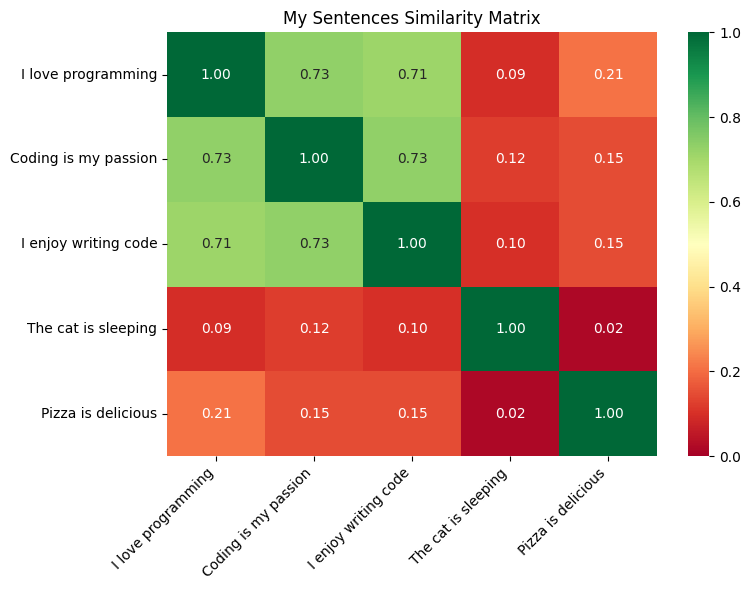

In [8]:
# TODO: 加入你自己的句子，觀察相似度
my_sentences = [
    "I love programming",
    "Coding is my passion",
    "I enjoy writing code",
    "The cat is sleeping",
    "Pizza is delicious",
]

my_embeddings = model.encode(my_sentences)
my_similarity = cosine_similarity(my_embeddings)

# 視覺化
plt.figure(figsize=(8, 6))
sns.heatmap(
    my_similarity,
    annot=True,
    fmt='.2f',
    xticklabels=my_sentences,
    yticklabels=my_sentences,
    cmap='RdYlGn',
    vmin=0, vmax=1
)
plt.title('My Sentences Similarity Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 🎨 Part 4: Embedding 視覺化

### 降維技術

Embedding 通常有數百維，無法直接視覺化。我們需要使用降維技術：

1. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**
   - 保持局部結構
   - 適合視覺化聚類
   - 計算較慢

2. **UMAP (Uniform Manifold Approximation and Projection)**
   - 同時保持局部和全局結構
   - 計算較快
   - 結果較穩定

In [9]:
# 準備更多樣化的資料用於視覺化
categories = {
    'Animals': [
        "The cat is sleeping on the sofa",
        "Dogs are loyal companions",
        "Birds can fly in the sky",
        "Fish swim in the ocean",
        "Elephants are the largest land animals",
    ],
    'Technology': [
        "Machine learning is transforming industries",
        "Python is a popular programming language",
        "GPUs accelerate deep learning training",
        "Cloud computing enables scalability",
        "Artificial intelligence mimics human cognition",
    ],
    'Food': [
        "Pizza is a delicious Italian dish",
        "Sushi is a traditional Japanese food",
        "Chocolate cake is a sweet dessert",
        "Fresh vegetables are healthy",
        "Coffee helps me wake up in the morning",
    ],
    'Sports': [
        "Basketball requires teamwork and skill",
        "Swimming is great exercise",
        "Football is popular worldwide",
        "Tennis is played with a racket",
        "Running improves cardiovascular health",
    ],
}

# 建立資料集
all_sentences = []
all_labels = []
for category, sentences in categories.items():
    all_sentences.extend(sentences)
    all_labels.extend([category] * len(sentences))

# 產生 embeddings
all_embeddings = model.encode(all_sentences)
print(f"✅ 產生了 {len(all_embeddings)} 個 embeddings")
print(f"📊 類別分布: {dict(zip(*np.unique(all_labels, return_counts=True)))}")

✅ 產生了 20 個 embeddings
📊 類別分布: {np.str_('Animals'): np.int64(5), np.str_('Food'): np.int64(5), np.str_('Sports'): np.int64(5), np.str_('Technology'): np.int64(5)}


🔄 正在執行 t-SNE 降維...


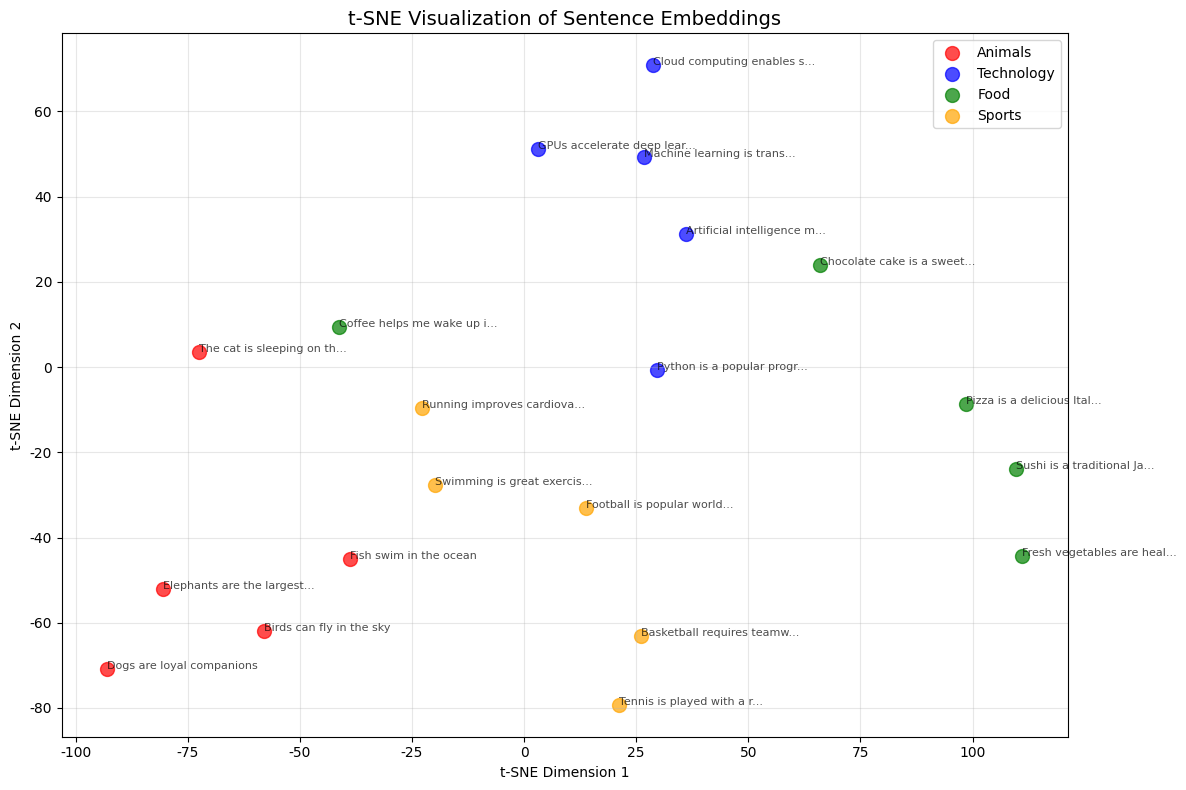


💡 觀察重點:
- 同類別的句子應該聚集在一起
- 不同類別之間應該有明顯分隔


In [10]:
# 使用 t-SNE 降維
print("🔄 正在執行 t-SNE 降維...")
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
embeddings_2d_tsne = tsne.fit_transform(all_embeddings)

# 視覺化
plt.figure(figsize=(12, 8))
colors = {'Animals': 'red', 'Technology': 'blue', 'Food': 'green', 'Sports': 'orange'}

for category in categories.keys():
    mask = np.array(all_labels) == category
    plt.scatter(
        embeddings_2d_tsne[mask, 0],
        embeddings_2d_tsne[mask, 1],
        c=colors[category],
        label=category,
        s=100,
        alpha=0.7
    )

# 加上文字標籤
for i, sentence in enumerate(all_sentences):
    plt.annotate(
        sentence[:25] + '...' if len(sentence) > 25 else sentence,
        (embeddings_2d_tsne[i, 0], embeddings_2d_tsne[i, 1]),
        fontsize=8,
        alpha=0.7
    )

plt.title('t-SNE Visualization of Sentence Embeddings', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 觀察重點:")
print("- 同類別的句子應該聚集在一起")
print("- 不同類別之間應該有明顯分隔")

🔄 正在執行 UMAP 降維...


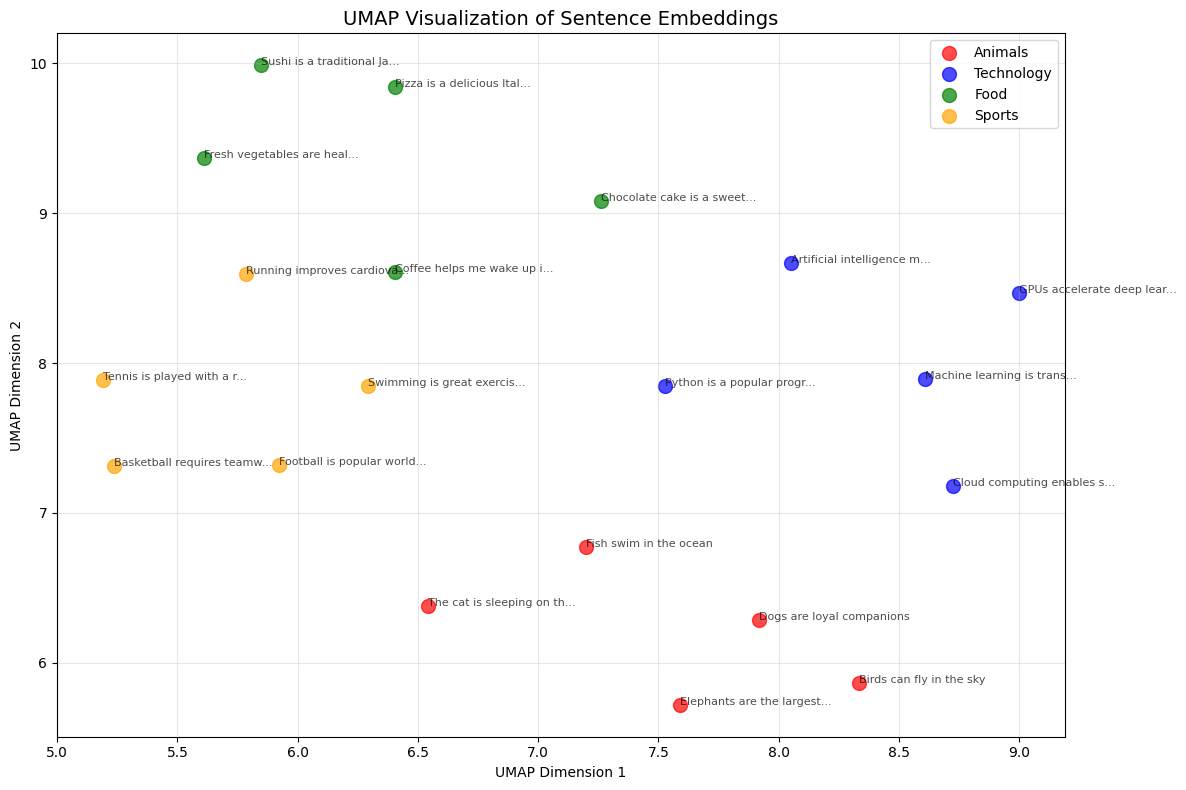

In [11]:
# 使用 UMAP 降維
try:
    import umap

    print("🔄 正在執行 UMAP 降維...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=5, min_dist=0.3)
    embeddings_2d_umap = reducer.fit_transform(all_embeddings)

    # 視覺化
    plt.figure(figsize=(12, 8))

    for category in categories.keys():
        mask = np.array(all_labels) == category
        plt.scatter(
            embeddings_2d_umap[mask, 0],
            embeddings_2d_umap[mask, 1],
            c=colors[category],
            label=category,
            s=100,
            alpha=0.7
        )

    # 加上文字標籤
    for i, sentence in enumerate(all_sentences):
        plt.annotate(
            sentence[:25] + '...' if len(sentence) > 25 else sentence,
            (embeddings_2d_umap[i, 0], embeddings_2d_umap[i, 1]),
            fontsize=8,
            alpha=0.7
        )

    plt.title('UMAP Visualization of Sentence Embeddings', fontsize=14)
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("⚠️ UMAP 未安裝，請執行: pip install umap-learn")

---
## 🔬 Part 5: 比較不同模型

不同的預訓練模型有不同的特性：
- **all-MiniLM-L6-v2**: 輕量快速，英文表現好
- **paraphrase-multilingual-MiniLM-L12-v2**: 多語言支援
- **BAAI/bge-small-zh-v1.5**: 中文專用模型

In [12]:
# 載入多個模型進行比較
models_to_compare = {
    'all-MiniLM-L6-v2': 'all-MiniLM-L6-v2',
    'multilingual-MiniLM': 'paraphrase-multilingual-MiniLM-L12-v2',
}

# 測試句子（包含中英文）
test_sentences = [
    ("I love machine learning", "機器學習很有趣"),
    ("The cat is cute", "這隻貓很可愛"),
    ("Weather is nice today", "今天天氣真好"),
]

print("🔄 載入模型中...\n")
loaded_models = {}
for name, model_name in models_to_compare.items():
    try:
        loaded_models[name] = SentenceTransformer(model_name)
        print(f"✅ {name} 載入成功")
    except Exception as e:
        print(f"❌ {name} 載入失敗: {e}")

🔄 載入模型中...



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ multilingual-MiniLM 載入成功


In [13]:
# 比較不同模型的跨語言能力
print("📊 跨語言相似度比較\n")
print("=" * 70)

for en, zh in test_sentences:
    print(f"\n英文: '{en}'")
    print(f"中文: '{zh}'")
    print("-" * 50)

    for model_name, m in loaded_models.items():
        emb_en = m.encode(en)
        emb_zh = m.encode(zh)
        sim = cosine_similarity([emb_en], [emb_zh])[0][0]
        print(f"  {model_name}: {sim:.4f}")

print("\n" + "=" * 70)
print("\n💡 觀察重點:")
print("- multilingual 模型在跨語言任務上表現更好")
print("- 英文專用模型對中文的處理能力有限")

📊 跨語言相似度比較


英文: 'I love machine learning'
中文: '機器學習很有趣'
--------------------------------------------------
  all-MiniLM-L6-v2: 0.0567
  multilingual-MiniLM: 0.7740

英文: 'The cat is cute'
中文: '這隻貓很可愛'
--------------------------------------------------
  all-MiniLM-L6-v2: 0.1986
  multilingual-MiniLM: 0.9877

英文: 'Weather is nice today'
中文: '今天天氣真好'
--------------------------------------------------
  all-MiniLM-L6-v2: 0.1498
  multilingual-MiniLM: 0.8455


💡 觀察重點:
- multilingual 模型在跨語言任務上表現更好
- 英文專用模型對中文的處理能力有限


---
## 🎯 Part 6: 語義相似 vs 字面相似

好的 Embedding 模型應該能夠：
- 識別語義相近但字面不同的句子
- 區分字面相似但語義不同的句子

In [14]:
# 測試語義理解能力
semantic_tests = [
    {
        'name': '同義句測試',
        'sentences': [
            "The movie was great",
            "The film was excellent",
            "I really enjoyed the movie",
        ],
        'expected': '應該都很相似'
    },
    {
        'name': '反義句測試',
        'sentences': [
            "I love this product",
            "I hate this product",
            "This product is terrible",
        ],
        'expected': '愛和恨應該不同'
    },
    {
        'name': '字面相似但語義不同',
        'sentences': [
            "The bank is near the river",
            "I need to go to the bank",
            "The river bank is beautiful",
        ],
        'expected': 'bank 有不同含義'
    },
]

for test in semantic_tests:
    print(f"\n🧪 {test['name']}")
    print(f"   預期: {test['expected']}")
    print("-" * 50)

    embs = model.encode(test['sentences'])
    sim_matrix = cosine_similarity(embs)

    for i, s1 in enumerate(test['sentences']):
        for j, s2 in enumerate(test['sentences']):
            if i < j:
                print(f"   '{s1[:30]}...' vs '{s2[:30]}...'")
                print(f"   相似度: {sim_matrix[i][j]:.4f}")
                print()


🧪 同義句測試
   預期: 應該都很相似
--------------------------------------------------
   'The movie was great...' vs 'The film was excellent...'
   相似度: 0.8782

   'The movie was great...' vs 'I really enjoyed the movie...'
   相似度: 0.8275

   'The film was excellent...' vs 'I really enjoyed the movie...'
   相似度: 0.7788


🧪 反義句測試
   預期: 愛和恨應該不同
--------------------------------------------------
   'I love this product...' vs 'I hate this product...'
   相似度: 0.6984

   'I love this product...' vs 'This product is terrible...'
   相似度: 0.6130

   'I hate this product...' vs 'This product is terrible...'
   相似度: 0.7696


🧪 字面相似但語義不同
   預期: bank 有不同含義
--------------------------------------------------
   'The bank is near the river...' vs 'I need to go to the bank...'
   相似度: 0.5926

   'The bank is near the river...' vs 'The river bank is beautiful...'
   相似度: 0.8038

   'I need to go to the bank...' vs 'The river bank is beautiful...'
   相似度: 0.4601



### 🏋️ 練習 2: 設計你自己的語義測試

設計一組測試來檢驗模型的語義理解能力。

In [15]:
# TODO: 設計你自己的測試
my_test = {
'name': '專業領域語義壓力測試 (ISO vs. 法律)',
    'sentences': [
        "公司應建立資訊安全管理系統以符合 ISO 27001 規範",     # A: ISO 規範 (正面)
        "組織必須依據 ISO 27001 標準實施風險評估程序",         # B: ISO 規範 (正面, 語義相近)
        "偽造、變造私文書，足以生損害於公眾或他人者，處五年以下有期徒刑", # C: 法律條文 (刑法)
        "意圖為自己或第三人不法之所有，而取他人之物者，為竊盜罪",       # D: 法律條文 (刑法, 但主題不同)
        "公司不需要建立任何資訊安全管理系統",                 # E: A 的反義句
    ],
    'expected': '1. A與B應極高(>0.85) | 2. A與C應明顯區分 | 3. A與E應比A與B低很多'
}

print(f"🧪 {my_test['name']}")
print(f"   預期: {my_test['expected']}")
print("-" * 50)

embs = model.encode(my_test['sentences'])
sim_matrix = cosine_similarity(embs)

for i, s1 in enumerate(my_test['sentences']):
    for j, s2 in enumerate(my_test['sentences']):
        if i < j:
            print(f"   '{s1}' vs '{s2}'")
            print(f"   相似度: {sim_matrix[i][j]:.4f}\n")

🧪 專業領域語義壓力測試 (ISO vs. 法律)
   預期: 1. A與B應極高(>0.85) | 2. A與C應明顯區分 | 3. A與E應比A與B低很多
--------------------------------------------------
   '公司應建立資訊安全管理系統以符合 ISO 27001 規範' vs '組織必須依據 ISO 27001 標準實施風險評估程序'
   相似度: 0.5124

   '公司應建立資訊安全管理系統以符合 ISO 27001 規範' vs '偽造、變造私文書，足以生損害於公眾或他人者，處五年以下有期徒刑'
   相似度: 0.6169

   '公司應建立資訊安全管理系統以符合 ISO 27001 規範' vs '意圖為自己或第三人不法之所有，而取他人之物者，為竊盜罪'
   相似度: 0.3285

   '公司應建立資訊安全管理系統以符合 ISO 27001 規範' vs '公司不需要建立任何資訊安全管理系統'
   相似度: 0.8956

   '組織必須依據 ISO 27001 標準實施風險評估程序' vs '偽造、變造私文書，足以生損害於公眾或他人者，處五年以下有期徒刑'
   相似度: 0.4725

   '組織必須依據 ISO 27001 標準實施風險評估程序' vs '意圖為自己或第三人不法之所有，而取他人之物者，為竊盜罪'
   相似度: 0.3495

   '組織必須依據 ISO 27001 標準實施風險評估程序' vs '公司不需要建立任何資訊安全管理系統'
   相似度: 0.4011

   '偽造、變造私文書，足以生損害於公眾或他人者，處五年以下有期徒刑' vs '意圖為自己或第三人不法之所有，而取他人之物者，為竊盜罪'
   相似度: 0.5523

   '偽造、變造私文書，足以生損害於公眾或他人者，處五年以下有期徒刑' vs '公司不需要建立任何資訊安全管理系統'
   相似度: 0.6297

   '意圖為自己或第三人不法之所有，而取他人之物者，為竊盜罪' vs '公司不需要建立任何資訊安全管理系統'
   相似度: 0.4657



---
## 📝 總結

### 本實驗學到的重點

1. **Embedding 基礎**
   - Embedding 將文字轉換為數值向量
   - 語義相近的文字，向量也相近

2. **相似度計算**
   - Cosine Similarity 是最常用的度量
   - 範圍 [-1, 1]，越接近 1 越相似

3. **視覺化技術**
   - t-SNE 和 UMAP 可將高維向量降到 2D
   - 有助於理解 embedding 空間的結構

4. **模型選擇**
   - 不同模型適合不同任務
   - 多語言模型適合跨語言應用

### 下一步
在 Lab 02 中，我們將學習如何量化評估 Embedding 模型的品質！

---
## 📚 參考資源

- [Sentence Transformers 文件](https://www.sbert.net/)
- [t-SNE 原理解說](https://distill.pub/2016/misread-tsne/)
- [UMAP 原理解說](https://umap-learn.readthedocs.io/en/latest/how_umap_works.html)
- [Embedding 可視化工具 - TensorFlow Projector](https://projector.tensorflow.org/)